In [1]:
from oggm.shop import bedtopo
from oggm import workflow
import xarray as xr  # Import xarray 
import matplotlib.pyplot as plt


In [2]:
from oggm import cfg, utils, workflow, tasks, graphics
cfg.initialize(logging_level='WARNING')

2025-01-09 19:20:28: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-01-09 19:20:28: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-01-09 19:20:28: oggm.cfg: Multiprocessing: using all available processors (N=16)


In [3]:
# Local working directory (where OGGM will write its output)
# WORKING_DIR = utils.gettempdir('OGGM_distr4')
cfg.PATHS['working_dir'] = '/home/usman/Music/GeeMap /OGGM/data'

In [4]:
rgi_ids = ['RGI60-14.01226']  # Fieschergletscher

In [5]:
# The RGI version to use
# Size of the map around the glacier.
prepro_border = 10
# Degree of processing level. This is OGGM specific and for the shop 1 is the one you want
from_prepro_level = 3
# URL of the preprocessed gdirs
# we use elevation bands flowlines here
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5'
gdirs = workflow.init_glacier_directories(rgi_ids,
                                          from_prepro_level=from_prepro_level,
                                          prepro_base_url=base_url,
                                          prepro_border=prepro_border)

2025-01-09 19:20:31: oggm.workflow: init_glacier_directories from prepro level 3 on 1 glaciers.
2025-01-09 19:20:31: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


In [6]:
gdir = gdirs[0]

In [7]:
from oggm.shop import bedtopo

In [8]:
workflow.execute_entity_task(bedtopo.add_consensus_thickness, gdirs);

2025-01-09 19:20:33: oggm.workflow: Execute entity tasks [add_consensus_thickness] on 1 glaciers


In [9]:

with xr.open_dataset(gdir.get_filepath('gridded_data')) as ds:
    ds = ds.load()


In [10]:
# plot the salem map background, make countries in grey
smap = ds.salem.get_map(countries=False)
smap.set_shapefile(gdir.read_shapefile('outlines'))
smap.set_topography(ds.topo.data);

In [11]:
gdir

<oggm.GlacierDirectory>
  RGI id: RGI60-14.01226
  Region: 14: South Asia West
  Subregion: 14-02: Karakoram                       
  Name: Chhateboi Glacier
  Glacier type: Glacier
  Terminus type: Land-terminating
  Status: Glacier or ice cap
  Area: 35.674 km2
  Lon, Lat: (73.8878, 36.7795)
  Grid (nx, ny): (102, 162)
  Grid (dx, dy): (94.0, -94.0)

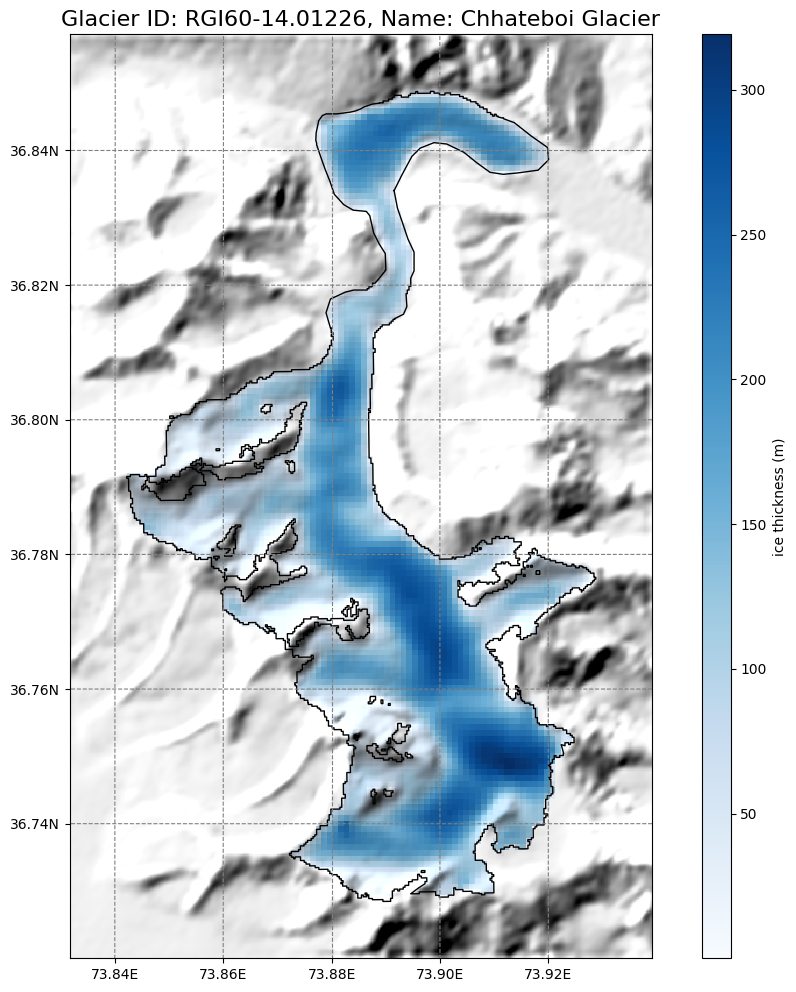

In [12]:
f, ax = plt.subplots(figsize=(12, 12))
smap.set_data(ds.consensus_ice_thickness)
smap.set_cmap('Blues')
smap.plot(ax=ax)
smap.append_colorbar(ax=ax, label='ice thickness (m)')

# Extract glacier ID and name from the dataset
glacier_id = ds.attrs.get("glacier_id", "RGI60-14.01226")
glacier_name = ds.attrs.get("glacier_name", "Chhateboi Glacier")

# Add title
ax.set_title(f"Glacier ID: {glacier_id}, Name: {glacier_name}", fontsize=16)

plt.savefig('/home/usman/Music/GeeMap/Results/ice_thickness_Chhateboi Glacier.png', dpi=500, bbox_inches='tight')


In [13]:
# attention downloads data!!!
from oggm.shop import millan22
workflow.execute_entity_task(millan22.velocity_to_gdir, gdirs);

2025-01-09 19:23:54: oggm.workflow: Execute entity tasks [velocity_to_gdir] on 1 glaciers


In [14]:
with xr.open_dataset(gdir.get_filepath('gridded_data')) as ds:
    ds = ds.load()
ds

<xarray.Dataset> Size: 447kB
Dimensions:                  (x: 102, y: 162)
Coordinates:
  * x                        (x) float32 408B -4.964e+03 -4.87e+03 ... 4.53e+03
  * y                        (y) float32 648B 4.079e+06 4.079e+06 ... 4.064e+06
Data variables:
    topo                     (y, x) float32 66kB 3.931e+03 ... 4.982e+03
    topo_smoothed            (y, x) float32 66kB 3.914e+03 ... 4.978e+03
    topo_valid_mask          (y, x) int8 17kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1
    glacier_mask             (y, x) int8 17kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    glacier_ext              (y, x) int8 17kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    consensus_ice_thickness  (y, x) float32 66kB nan nan nan nan ... nan nan nan
    millan_v                 (y, x) float32 66kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    millan_vx                (y, x) float32 66kB nan nan nan nan ... nan nan nan
    millan_vy                (y, x) float32 66kB nan nan nan nan ... nan nan nan
Attributes:
    author:         OGGM
    author_info:    Open Global Glacier Model
    pyproj_srs:     +proj=tmerc +lat_0=0 +lon_0=73.8878 +k=0.9996 +x_0=0 +y_0...
    max_h_dem:      6168.0
    min_h_dem:      3485.0
    max_h_glacier:  6168.0
    min_h_glacier:  3557.0

In [15]:
# plot the salem map background, make countries in grey
smap = ds.salem.get_map(countries=False)
smap.set_shapefile(gdir.read_shapefile('outlines'))
smap.set_topography(ds.topo.data);

In [16]:
ds

<xarray.Dataset> Size: 447kB
Dimensions:                  (x: 102, y: 162)
Coordinates:
  * x                        (x) float32 408B -4.964e+03 -4.87e+03 ... 4.53e+03
  * y                        (y) float32 648B 4.079e+06 4.079e+06 ... 4.064e+06
Data variables:
    topo                     (y, x) float32 66kB 3.931e+03 ... 4.982e+03
    topo_smoothed            (y, x) float32 66kB 3.914e+03 ... 4.978e+03
    topo_valid_mask          (y, x) int8 17kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1
    glacier_mask             (y, x) int8 17kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    glacier_ext              (y, x) int8 17kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    consensus_ice_thickness  (y, x) float32 66kB nan nan nan nan ... nan nan nan
    millan_v                 (y, x) float32 66kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    millan_vx                (y, x) float32 66kB nan nan nan nan ... nan nan nan
    millan_vy                (y, x) float32 66kB nan nan nan nan ... nan nan nan
Attributes:
    author:         OGGM
    author_info:    Open Global Glacier Model
    pyproj_srs:     +proj=tmerc +lat_0=0 +lon_0=73.8878 +k=0.9996 +x_0=0 +y_0...
    max_h_dem:      6168.0
    min_h_dem:      3485.0
    max_h_glacier:  6168.0
    min_h_glacier:  3557.0

In [17]:
# get the velocity data
u = ds.millan_vx.where(ds.glacier_mask)
v = ds.millan_vy.where(ds.glacier_mask)
ws = (u**2 + v**2)**0.5

In [18]:
gdir

<oggm.GlacierDirectory>
  RGI id: RGI60-14.01226
  Region: 14: South Asia West
  Subregion: 14-02: Karakoram                       
  Name: Chhateboi Glacier
  Glacier type: Glacier
  Terminus type: Land-terminating
  Status: Glacier or ice cap
  Area: 35.674 km2
  Lon, Lat: (73.8878, 36.7795)
  Grid (nx, ny): (102, 162)
  Grid (dx, dy): (94.0, -94.0)

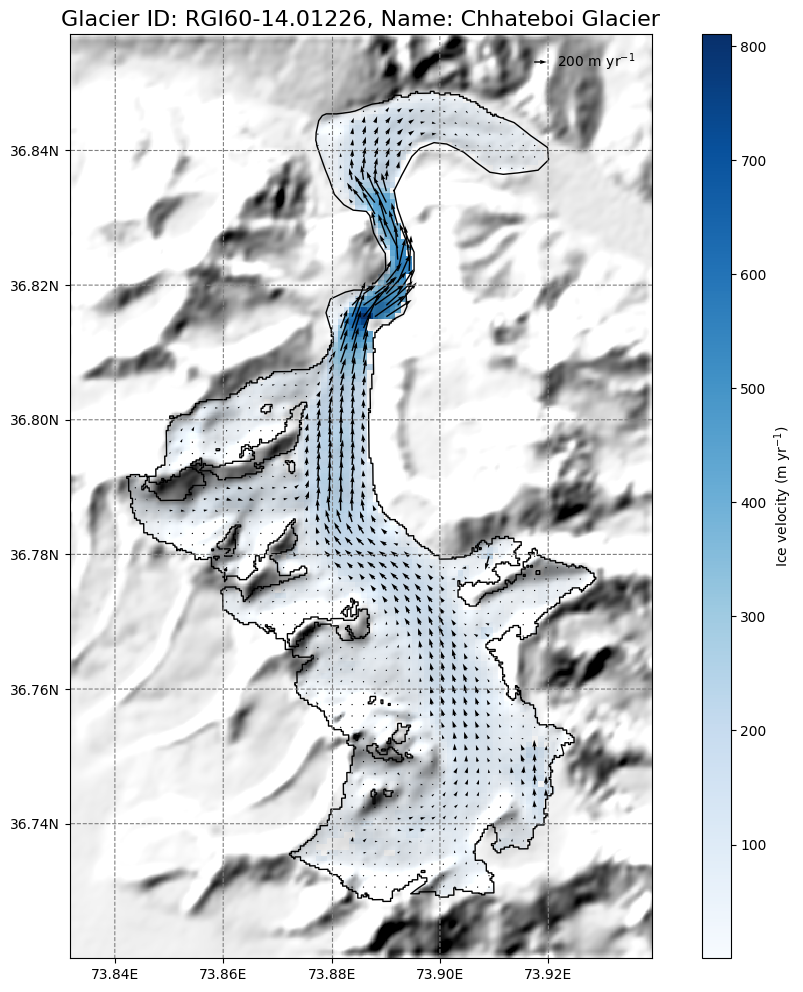

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Get the axes ready
f, ax = plt.subplots(figsize=(12, 12))

# Quiver only every 2nd grid point for clarity
us = u[1::2, 1::2]
vs = v[1::2, 1::2]

# Set ice velocity data
smap.set_data(ws)
smap.set_cmap('Blues')
smap.plot(ax=ax)
smap.append_colorbar(ax=ax, label='Ice velocity (m yr$^{-1}$)')

# Transform coordinates to the map reference system and plot arrows
xx, yy = smap.grid.transform(us.x.values, us.y.values, crs=gdir.grid.proj)
xx, yy = np.meshgrid(xx, yy)
qu = ax.quiver(xx, yy, us.values, vs.values)
qk = ax.quiverkey(qu, 0.82, 0.97, 200, '200 m yr$^{-1}$',
                  labelpos='E', coordinates='axes')

# Dynamic title with glacier information
# Extract glacier ID and name from the dataset
glacier_id = ds.attrs.get("glacier_id", "RGI60-14.01226")
glacier_name = ds.attrs.get("glacier_name", "Chhateboi Glacier")
ax.set_title(f"Glacier ID: {glacier_id}, Name: {glacier_name}", fontsize=16)

# Save the plot
plt.savefig('/home/usman/Music/GeeMap/Results/ice_velocity_Karambar Glacier.png', dpi=500, bbox_inches='tight')
